# Feature Engineering + Autoencoder — Sobresaturación Temporal
Trabajo Final — Introducción al Aprendizaje de Máquinas
Rodriguez Nelson / Benitez Mirna

Detecta anomalías de sobresaturación temporal en el consumo de medicamentos por
afiliado, agregando dispensas en ventanas semanales y entrenando un Autoencoder
no supervisado sobre ese vector de features.

## 0. Carga de datos

In [29]:
from google.colab import drive
drive.mount('/content/drive')

# Ajustar la ruta al CSV real una vez subido a Drive
RUTA_DATASET = '/content/drive/My Drive/DOCTORADO 2026/Introduccion al aprendizaje de Maquinas/Dataset/Activo_Pasivo/Salida/df_PUBLICO_combined_total.csv'
# RUTA_SALIDA ahora será el directorio para los resultados
RUTA_SALIDA_DIR = '/content/drive/My Drive/DOCTORADO 2026/Introduccion al aprendizaje de Maquinas/Dataset/Activo_Pasivo/Salida/'

import os
os.makedirs(RUTA_SALIDA_DIR, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

df = pd.read_csv(RUTA_DATASET, parse_dates=['F. Receta', 'F.Validac.'])
print(f'Dataset cargado: {df.shape}')


/tmp/ipykernel_4600/1067270549.py:6: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RUTA_DATASET, parse_dates=['F. Receta', 'F.Validac.'])


Dataset cargado: (512396, 40)


In [ ]:
df.head(2)

,CUIT,Razon Social,Nombre Fantasia,calle_nombre,calle_altura,localidad_nombre,Provincia,F.Validac.,Nro. Receta,Nro.item,...,Laboratorio,Labo_Id,Prestador,Presentacion fcia,ID externo,Recetario Orig,semana,CUF_hashed,Nro.Afil_hashed,Afiliado_hashed
0,30687986993,FARMACIA DEL PUENTE SCS,DEL PUENTE,AVENIDA JUAN RAMON VIDAL,1609,CORRIENTES,CORRIENTES,2026-04-01 00:04:28.559095,2609063541081,1,...,Siegfried,903,NaN,105239003395358682,0,2609063541081,2026-03-30,cf5da9fd80b6af3c56cb69005df18513c274f5c3fe5886...,b8d7c6664c7c9473b145b73290266c28e27525c2cadc9e...,285ba0bad75afbe7729bab3d6425eb7c3cf5dfeb4eb279...
1,33582664639,FARMACIA CATEDRAL S C S,CATEDRAL,SAN LORENZO,910,CORRIENTES,CORRIENTES,2026-04-01 01:11:38.540070,2608963461507,1,...,Roemmers,203,NaN,105239003145353745,0,2608963461507,2026-03-30,713e5b7284df2b7d755621cee814117ee04fca63b4157e...,eadd229ee85d59747c7ca78b9ea561fc2975391e3c2b26...,99f9bd6477af2eaf04e252abe70c382d04369321a88f31...


Eliminamos las columnas y registros con campos vacios.

In [31]:
df = df.drop(columns=['Prestador', 'Ctro Costo'])
print(f"Columnas eliminadas. Nueva forma del DataFrame: {df.shape}")

df = df.dropna(subset=['T.mat', 'nro.mat.', 'medico', 'codigobarra'])
print(f"Filas con valores nulos en columnas clave eliminadas. Nueva forma del DataFrame: {df.shape}")

Columnas eliminadas. Nueva forma del DataFrame: (512396, 38)
Filas con valores nulos en columnas clave eliminadas. Nueva forma del DataFrame: (512382, 38)


In [32]:
df.head(2)

,CUIT,Razon Social,Nombre Fantasia,calle_nombre,calle_altura,localidad_nombre,Provincia,F.Validac.,Nro. Receta,Nro.item,...,nrodoc,Laboratorio,Labo_Id,Presentacion fcia,ID externo,Recetario Orig,semana,CUF_hashed,Nro.Afil_hashed,Afiliado_hashed
0,30687986993,FARMACIA DEL PUENTE SCS,DEL PUENTE,AVENIDA JUAN RAMON VIDAL,1609,CORRIENTES,CORRIENTES,2026-04-01 00:04:28.559095,2609063541081,1,...,17813121,Siegfried,903,105239003395358682,0,2609063541081,2026-03-30,cf5da9fd80b6af3c56cb69005df18513c274f5c3fe5886...,b8d7c6664c7c9473b145b73290266c28e27525c2cadc9e...,285ba0bad75afbe7729bab3d6425eb7c3cf5dfeb4eb279...
1,33582664639,FARMACIA CATEDRAL S C S,CATEDRAL,SAN LORENZO,910,CORRIENTES,CORRIENTES,2026-04-01 01:11:38.540070,2608963461507,1,...,39519642,Roemmers,203,105239003145353745,0,2608963461507,2026-03-30,713e5b7284df2b7d755621cee814117ee04fca63b4157e...,eadd229ee85d59747c7ca78b9ea561fc2975391e3c2b26...,99f9bd6477af2eaf04e252abe70c382d04369321a88f31...


## 1. Feature engineering: agregación semanal por afiliado

In [33]:
t0 = time.time()

df['semana'] = df['F. Receta'].dt.to_period('W-SUN').dt.start_time
df['monto_neto'] = (df['P.Venta'] - df['Desc.']) * df['Cantidad']

g = df.groupby(['Nro.Afil_hashed', 'semana'])

features = g.agg(
    n_dispensas=('Cod.Valid.', 'count'),
    n_farmacias_distintas=('CUIT', 'nunique'),
    n_medicos_distintos=('nro.mat.', 'nunique'),
    n_principios_activos_distintos=('p.Activo', 'nunique'),
    cantidad_total=('Cantidad', 'sum'),
    monto_total=('monto_neto', 'sum'),
    edad=('Edad (años)', 'first'),
    plan=('Plan', 'first'),
).reset_index()

print(f'Filas afiliado-semana: {features.shape[0]:,}  |  {time.time()-t0:.1f}s')


Filas afiliado-semana: 284,872  |  0.6s


In [34]:
cant_por_principio = df.groupby(['Nro.Afil_hashed', 'semana', 'p.Activo'])['Cantidad'].sum().reset_index()
cant_max_principio = (cant_por_principio.groupby(['Nro.Afil_hashed', 'semana'])['Cantidad']
                       .max().reset_index()
                       .rename(columns={'Cantidad': 'cantidad_max_mismo_principio'}))
features = features.merge(cant_max_principio, on=['Nro.Afil_hashed', 'semana'], how='left')

# Dias desde la ultima dispensa del mismo principio activo (minimo por semana)
df_sorted = df.sort_values(['Nro.Afil_hashed', 'p.Activo', 'F. Receta'])
df_sorted['dias_desde_ultima_misma_droga'] = (
    df_sorted.groupby(['Nro.Afil_hashed', 'p.Activo'])['F. Receta'].diff().dt.days
)
dias_min = (df_sorted.groupby(['Nro.Afil_hashed', 'semana'])['dias_desde_ultima_misma_droga']
            .min().reset_index()
            .rename(columns={'dias_desde_ultima_misma_droga': 'dias_min_recompra_misma_droga'}))
features = features.merge(dias_min, on=['Nro.Afil_hashed', 'semana'], how='left')

# Crear la bandera binaria para NaN y luego imputar la mediana
features['dias_min_recompra_misma_droga_nan_flag'] = features['dias_min_recompra_misma_droga'].isna().astype(int)
median_recompra = features['dias_min_recompra_misma_droga'].median()
features['dias_min_recompra_misma_droga'] = features['dias_min_recompra_misma_droga'].fillna(median_recompra)

print(features.shape)
features.head()

(284872, 13)


,Nro.Afil_hashed,semana,n_dispensas,n_farmacias_distintas,n_medicos_distintos,n_principios_activos_distintos,cantidad_total,monto_total,edad,plan,cantidad_max_mismo_principio,dias_min_recompra_misma_droga,dias_min_recompra_misma_droga_nan_flag
0,0001ac6bf113f5005b6e128fff18c4dd7f74f3d92897a0...,2026-03-16,1,1,1,1,1,9687.50,55.0,1139,1,31.0,1
1,0001ac6bf113f5005b6e128fff18c4dd7f74f3d92897a0...,2026-05-11,1,1,1,1,1,36700.27,55.0,1139,1,31.0,1
2,0001ac6bf113f5005b6e128fff18c4dd7f74f3d92897a0...,2026-06-22,1,1,1,1,1,13533.28,55.0,1139,1,31.0,1
3,000291251ae2d5298d16f80a7df04ffbf1882a5221694d...,2026-01-19,3,1,1,3,3,25454.44,55.0,1139,1,31.0,1
4,000291251ae2d5298d16f80a7df04ffbf1882a5221694d...,2026-02-23,1,1,1,1,1,31128.85,55.0,1139,1,31.0,1


## 2. Reglas de negocio (Solo para evaluación, no entran al modelo, hay que seguir ajustandolas)

In [35]:
features['regla_A_muchas_farmacias'] = features['n_farmacias_distintas'] >= 3
features['regla_B_acumulacion_droga'] = features['cantidad_max_mismo_principio'] >= 3
features['regla_C_recompra_temprana'] = features['dias_min_recompra_misma_droga'] < 5

features['flag_regla_negocio'] = (
    features['regla_A_muchas_farmacias']
    | features['regla_B_acumulacion_droga']
    | features['regla_C_recompra_temprana']
)

print(f"Semanas marcadas: {features['flag_regla_negocio'].sum():,} de {len(features):,} "
      f"({100*features['flag_regla_negocio'].mean():.3f}%)")

for col in ['regla_A_muchas_farmacias','regla_B_acumulacion_droga','regla_C_recompra_temprana']:
    print(f"{col:35s}: {features[col].sum():,} ({100*features[col].mean():.3f}%)")

features.to_csv(RUTA_SALIDA_DIR + 'features_afiliado_semana.csv', index=False)

Semanas marcadas: 6,783 de 284,872 (2.381%)
regla_A_muchas_farmacias           : 623 (0.219%)
regla_B_acumulacion_droga          : 401 (0.141%)
regla_C_recompra_temprana          : 6,219 (2.183%)


## 3. Preprocesamiento: split + escalado

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Chequeo rápido: confirmar que Plan solo tiene los 2 códigos esperados
print(features['plan'].value_counts())

# Transformación log ANTES de armar feature_cols, para poder incluirlas
features['monto_total_log'] = np.log1p(features['monto_total'].clip(lower=0))
features['cantidad_total_log'] = np.log1p(features['cantidad_total'])

feature_cols = [
    'n_dispensas', 'n_farmacias_distintas', 'n_medicos_distintos',
    'n_principios_activos_distintos',
    'cantidad_total_log', 'monto_total_log',
    'cantidad_max_mismo_principio', 'dias_min_recompra_misma_droga', 'edad',
    'dias_min_recompra_misma_droga_nan_flag' # Añadir el nuevo flag como feature
]

features['plan_bin'] = (features['plan'] == 1157).astype(int)  # 1 = PASIVO, 0 = ACTIVO
feature_cols.append('plan_bin')

X = features[feature_cols].values # El fillna(0) para dias_min_recompra_misma_droga ya se hizo, se mantiene para otras posibles NaN
flag_regla = features['flag_regla_negocio'].values

X_train_full, X_test, flag_train_full, flag_test = train_test_split(
    X, flag_regla, test_size=0.2, random_state=42
)

X_train_limpio = X_train_full[~flag_train_full]
print(f'Train limpio: {X_train_limpio.shape[0]:,} de {X_train_full.shape[0]:,}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_limpio)
X_test_scaled = scaler.transform(X_test)

plan
1139    160823
1157    124049
Name: count, dtype: int64
Train limpio: 222,464 de 227,897


## 4. Arquitectura del Autoencoder
Dimensionada al vector de 10 features (16→8→4→8→16), para evitar sobreajuste dado el tamaño reducido de entrada tras acotar el alcance del proyecto.

In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

input_dim = X_train_scaled.shape[1]

inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(16, activation='relu')(inputs)
x = layers.Dense(8, activation='relu')(x)
bottleneck = layers.Dense(4, activation='relu', name='bottleneck')(x)
x = layers.Dense(8, activation='relu')(bottleneck)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(input_dim, activation='linear')(x)

autoencoder = keras.Model(inputs, outputs, name='autoencoder_sobresaturacion')
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "autoencoder_sobresaturacion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 11)             │           187 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 735 (2.87 KB)

 Trainable params: 735 (2.87 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento

Epoch 1/30
783/783 - 3s - 4ms/step - loss: 0.4040 - val_loss: 0.1965
Epoch 2/30
783/783 - 2s - 2ms/step - loss: 0.1624 - val_loss: 0.1348
Epoch 3/30
783/783 - 2s - 2ms/step - loss: 0.1194 - val_loss: 0.1013
Epoch 4/30
783/783 - 2s - 2ms/step - loss: 0.0925 - val_loss: 0.0821
Epoch 5/30
783/783 - 2s - 2ms/step - loss: 0.0764 - val_loss: 0.0674
Epoch 6/30
783/783 - 3s - 3ms/step - loss: 0.0651 - val_loss: 0.0577
Epoch 7/30
783/783 - 2s - 3ms/step - loss: 0.0549 - val_loss: 0.0475
Epoch 8/30
783/783 - 2s - 2ms/step - loss: 0.0463 - val_loss: 0.0404
Epoch 9/30
783/783 - 2s - 2ms/step - loss: 0.0401 - val_loss: 0.0353
Epoch 10/30
783/783 - 2s - 2ms/step - loss: 0.0356 - val_loss: 0.0316
Epoch 11/30
783/783 - 2s - 2ms/step - loss: 0.0325 - val_loss: 0.0293
Epoch 12/30
783/783 - 2s - 2ms/step - loss: 0.0304 - val_loss: 0.0274
Epoch 13/30
783/783 - 2s - 2ms/step - loss: 0.0284 - val_loss: 0.0256
Epoch 14/30
783/783 - 2s - 3ms/step - loss: 0.0266 - val_loss: 0.0240
Epoch 15/30
783/783 - 2s - 3m

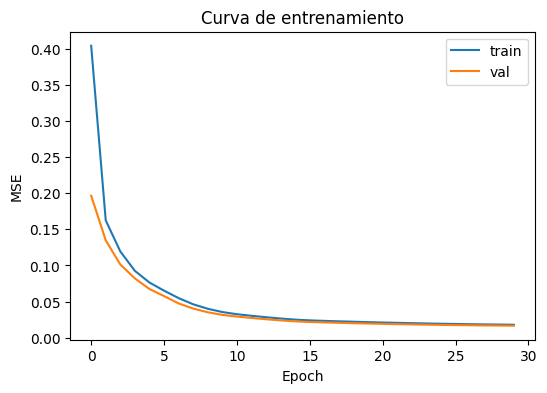

In [38]:
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    verbose=2,
)

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend()
plt.title('Curva de entrenamiento')
plt.savefig(RUTA_SALIDA_DIR + 'curva_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Score de anomalía y umbral

In [39]:
recon_train = autoencoder.predict(X_train_scaled, verbose=0)
mse_train = np.mean(np.square(X_train_scaled - recon_train), axis=1)
umbral = np.percentile(mse_train, 95)
print(f'Umbral (percentil 95, train limpio): {umbral:.4f}')

recon_test = autoencoder.predict(X_test_scaled, verbose=0)
mse_test = np.mean(np.square(X_test_scaled - recon_test), axis=1)
pred_anomalia = mse_test > umbral


Umbral (percentil 95, train limpio): 0.0797


## 7. Evaluación contra reglas de negocio

In [40]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve,
                             precision_recall_curve)

precision = precision_score(flag_test, pred_anomalia)
recall = recall_score(flag_test, pred_anomalia)
f1 = f1_score(flag_test, pred_anomalia)
auc = roc_auc_score(flag_test, mse_test)
cm = confusion_matrix(flag_test, pred_anomalia)

print(f'Precision: {precision:.3f}')
print(f'Recall:    {recall:.3f}')
print(f'F1:        {f1:.3f}')
print(f'AUC:       {auc:.3f}')
print(f'Matriz de confusion:\n{cm}')


Precision: 0.310
Recall:    0.919
F1:        0.464
AUC:       0.969
Matriz de confusion:
[[52867  2758]
 [  110  1240]]


## 8. Figuras para el informe

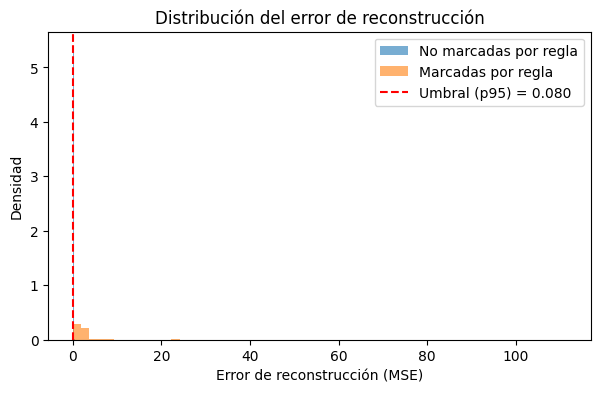

In [41]:
# Figura A: distribución del error de reconstrucción por grupo
plt.figure(figsize=(7,4))
plt.hist(mse_test[~flag_test], bins=60, alpha=0.6, label='No marcadas por regla', density=True)
plt.hist(mse_test[flag_test], bins=60, alpha=0.6, label='Marcadas por regla', density=True)
plt.axvline(umbral, color='red', linestyle='--', label=f'Umbral (p95) = {umbral:.3f}')
plt.xlabel('Error de reconstrucción (MSE)')
plt.ylabel('Densidad')
plt.legend()
plt.title('Distribución del error de reconstrucción')
plt.savefig(RUTA_SALIDA_DIR + 'fig_distribucion_error.png', dpi=150, bbox_inches='tight')
plt.show()

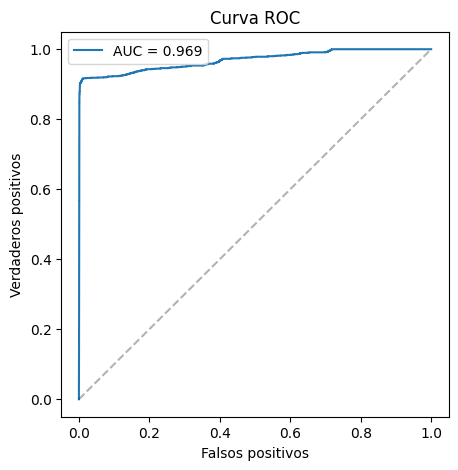

In [42]:
# Figura B: curva ROC
fpr, tpr, _ = roc_curve(flag_test, mse_test)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], 'k--', alpha=0.3)
plt.xlabel('Falsos positivos')
plt.ylabel('Verdaderos positivos')
plt.title('Curva ROC')
plt.legend()
plt.savefig(RUTA_SALIDA_DIR + 'fig_roc.png', dpi=150, bbox_inches='tight')
plt.show()

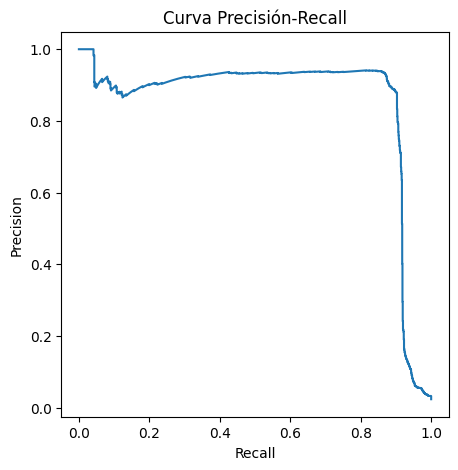

In [43]:
# Figura C: curva precision-recall segun umbral
prec_curve, rec_curve, _ = precision_recall_curve(flag_test, mse_test)
plt.figure(figsize=(5,5))
plt.plot(rec_curve, prec_curve)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precisión-Recall')
plt.savefig(RUTA_SALIDA_DIR + 'fig_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Guardar artefactos (modelo, resultados)

In [44]:
resultados = pd.DataFrame(X_test, columns=feature_cols)
resultados['mse_reconstruccion'] = mse_test
resultados['flag_regla_negocio'] = flag_test
resultados['marcado_autoencoder'] = pred_anomalia
resultados.to_csv(RUTA_SALIDA_DIR + 'resultados_test_autoencoder.csv', index=False)

autoencoder.save(RUTA_SALIDA_DIR + 'autoencoder_sobresaturacion.keras')

print('Artefactos guardados en', RUTA_SALIDA_DIR)

Artefactos guardados en /content/drive/My Drive/DOCTORADO 2026/Introduccion al aprendizaje de Maquinas/Dataset/Activo_Pasivo/Salida/


## 10. Casos concretos detectados (tabla informe)

In [48]:
top_casos = resultados.sort_values('mse_reconstruccion', ascending=False).head(15)
top_casos


,n_dispensas,n_farmacias_distintas,n_medicos_distintos,n_principios_activos_distintos,cantidad_total_log,monto_total_log,cantidad_max_mismo_principio,dias_min_recompra_misma_droga,edad,dias_min_recompra_misma_droga_nan_flag,plan_bin,mse_reconstruccion,flag_regla_negocio,marcado_autoencoder
8637,4.0,3.0,1.0,2.0,2.302585,0.000000,8.0,2.0,55.0,0.0,0.0,111.340901,True,True
25526,3.0,1.0,2.0,1.0,2.079442,0.000000,7.0,0.0,55.0,0.0,1.0,93.277091,True,True
14444,3.0,1.0,1.0,1.0,1.945910,0.000000,6.0,0.0,55.0,0.0,0.0,70.259240,True,True
45494,3.0,1.0,1.0,2.0,2.079442,0.000000,6.0,1.0,55.0,0.0,1.0,68.035777,True,True
47485,6.0,2.0,1.0,1.0,1.945910,11.857298,6.0,0.0,55.0,0.0,1.0,59.154343,True,True
5275,2.0,1.0,1.0,1.0,1.791759,0.000000,5.0,0.0,55.0,0.0,1.0,44.387579,True,True
35296,3.0,1.0,1.0,1.0,1.791759,0.000000,5.0,2.0,55.0,0.0,1.0,42.089083,True,True
53635,5.0,2.0,1.0,1.0,1.791759,10.904709,5.0,0.0,55.0,0.0,0.0,34.928264,True,True
2330,5.0,2.0,2.0,2.0,1.945910,10.648329,5.0,0.0,55.0,0.0,0.0,30.031013,True,True
15669,6.0,5.0,1.0,5.0,1.945910,10.778910,2.0,2.0,55.0,0.0,1.0,27.890125,True,True
